In [50]:
## Priscilla Angelina Zavala
## GRAD 50500: Week 3 Assignment 1 using Jupyter Notebook 

In [51]:
# Import iris dataset
from sklearn import datasets
iris = datasets.load_iris()

# Plantgrowth dataframe
import pandas as pd
plant_growth_data = { "weight": [4.17, 5.58, 5.18, 6.11, 4.50, 4.61, 5.17, 4.53, 5.33, 
                    5.14, 4.81, 4.17, 4.41, 3.59, 5.87, 3.83, 6.03, 4.89, 
                    4.32, 4.69, 6.31, 5.12, 5.54, 5.50, 5.37, 5.29, 4.92, 
                    6.15, 5.80, 5.26], 
                    "group": ["ctrl"] * 10 + ["trt1"] * 10 + ["trt2"] * 10}
PlantGrowth = pd.DataFrame(plant_growth_data)

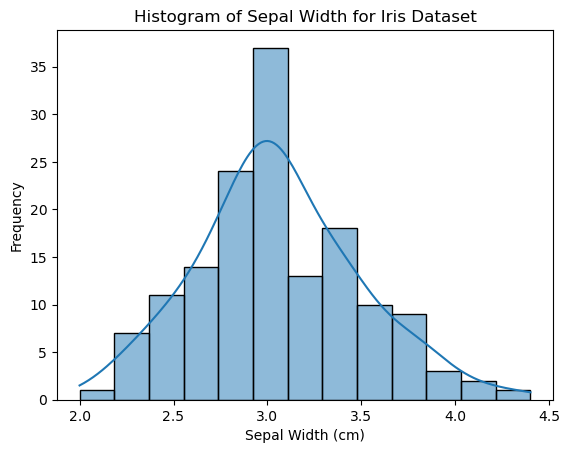

In [52]:
#### USING IRIRS DATASET ####
## a.) Make a histogram of the variable Sepal.Width.

# Using seaborn w/ matplotlib 
import seaborn as sns
import matplotlib.pyplot as plt   

# Sepal Width is second column, so I'm using iris.data[:, 1] to access it
# As referred to in lecture videos, kde=True adds kernel density estimate
sns.histplot(iris.data[:, 1], kde=True)

# Add titles and labels to histogram
plt.title('Histogram of Sepal Width for Iris Dataset')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')

# Display histogram
plt.show()


In [53]:
## b.) Based on the histogram from 1a, which would you expect to be higher,
## the mean or the median? Why?

'''
Based on the histogram from 1a, I would expect the mean to be slightly 
higher than the median because the histogram is right-skewed, which means 
there are larger values pulling the mean a little more to the right. 
This also means the median would be slightly lower than the mean because 
it's slightly less affected by extreme values. 
'''

"\nBased on the histogram from 1a, I would expect the mean to be slightly \nhigher than the median because the histogram is right-skewed, which means \nthere are larger values pulling the mean a little more to the right. \nThis also means the median would be slightly lower than the mean because \nit's slightly less affected by extreme values. \n"

In [54]:
## c.) Confirm your answer to #1b by actually finding these values.

# Import numpy to calculate mean and median
import numpy as np

mean_sepal_width = np.mean(iris.data[:, 1])
median_sepal_width = np.median(iris.data[:, 1])

# Print the mean and median values, rounding to hundreths 
# for better formatting
print(f'Mean Sepal Width: {mean_sepal_width:.2f}')
print(f'Median Sepal Width: {median_sepal_width:.2f}')


Mean Sepal Width: 3.06
Median Sepal Width: 3.00


In [55]:
## d.) Only 27% of the flowers have a Sepal.Width higher than ________ cm.

# Finding value at 73rd percentile (100% - 27% = 73%)
seapl_width_73rd_percentile = np.percentile(iris.data[:, 1], 73)

# Print value at 73rd percentile, rounding to hundreths 
print(f'Only 27% of flowers have a Sepal Width higher than: {seapl_width_73rd_percentile:.2f} cm')

Only 27% of flowers have a Sepal Width higher than: 3.30 cm


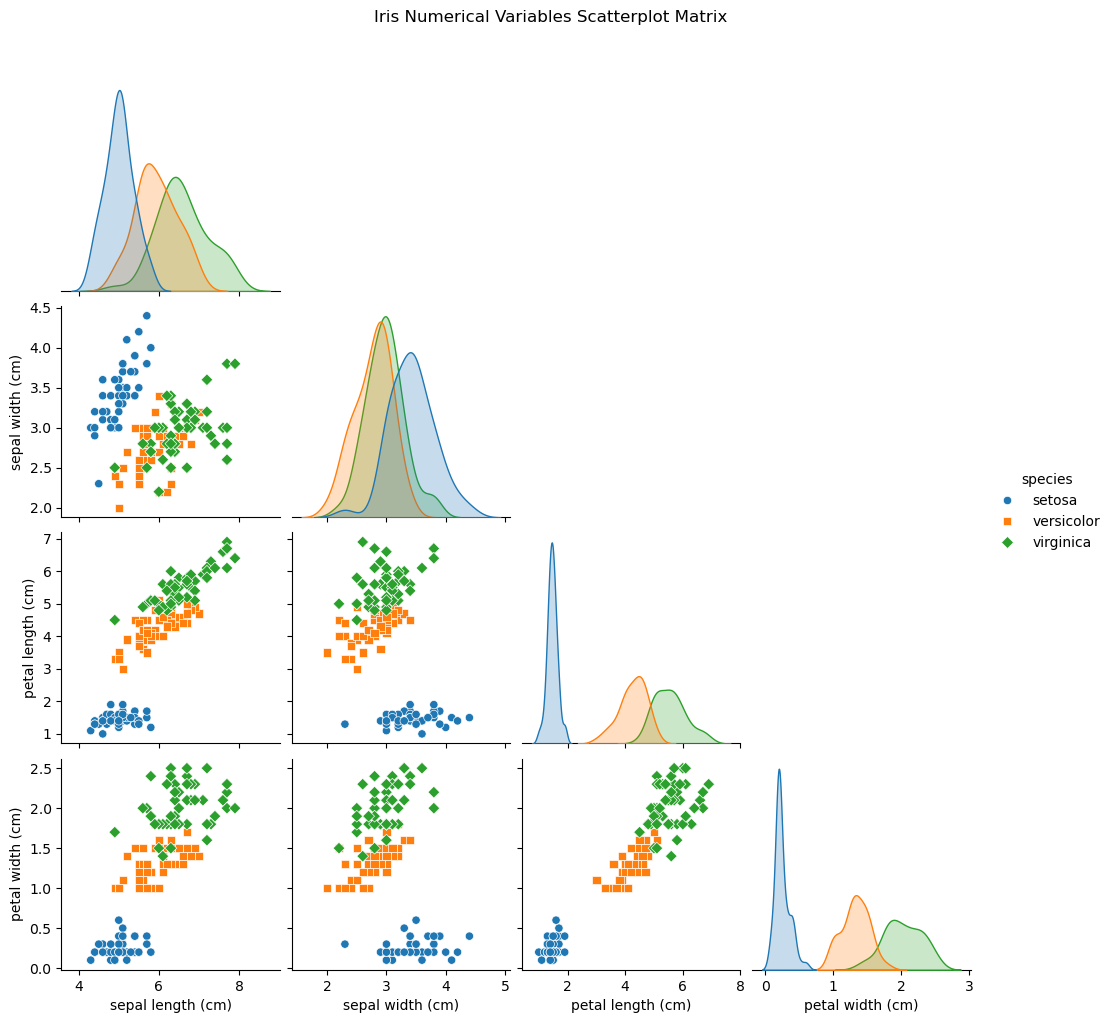

In [56]:
## e.) Make scatterplots of each pair of the numerical variables in iris 
## (There should be 6 pairs/plots).

# Create data frame of all numerical variables from iris dataset 
# for easier plotting
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Target species for color coding
iris_df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Create scatterplot grid for all numeric pairs
iris_num_scatter = sns.pairplot(iris_df, 
                                hue="species", 
                                corner=True, markers=["o", "s", "D"])

# Add overall title for scatterplots
# Adjust top spacing to avoid overlap with scatterplots for better formatting
iris_num_scatter.figure.suptitle("Iris Numerical Variables Scatterplot Matrix", 
                                 y=1.02)
iris_num_scatter.figure.subplots_adjust(top=0.95)

plt.show()


In [57]:
## f.) Based on 1e, which two variables appear to have the strongest 
## relationship? And which two appear to have the weakest relationship?

'''
Based on the scatterplots in 1e, petal length and petal width appear to
have the strongest relationship because the points are closely clustered 
and have a strong positive linear relationship. 
Sepal length and sepal width appear to have the weekest relationship 
because the points are more scattered and do not show a clear linear 
relationship. It is also clear to see there is no strong correlation
between the two numeric variables. 
'''


'\nBased on the scatterplots in 1e, petal length and petal width appear to\nhave the strongest relationship because the points are closely clustered \nand have a strong positive linear relationship. \nSepal length and sepal width appear to have the weekest relationship \nbecause the points are more scattered and do not show a clear linear \nrelationship. It is also clear to see there is no strong correlation\nbetween the two numeric variables. \n'

Max weight value: 6.31


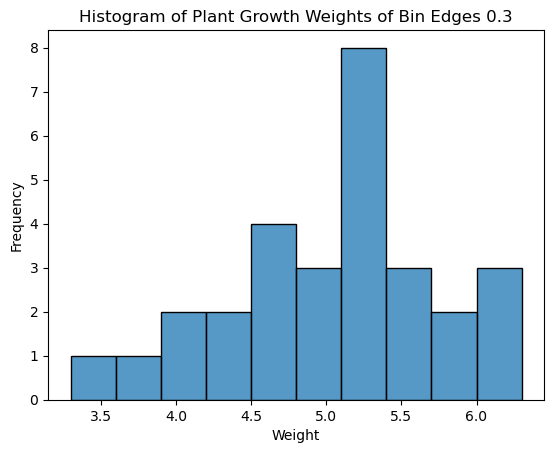

In [58]:
#### USING PLANTGROWTH DATASET ####
## a.) Make a histogram of the variable weight with breakpoints 
## (bin edges) at every 0.3 units, starting at 3.3.

# Print max value of weight to determine the end of the bins
print(f'Max weight value: {PlantGrowth["weight"].max()}')

# Histogram of weight with bins at every 0.3, starting at 3.3, 
# kde=False to remove kernel density estimate
sns.histplot(
    PlantGrowth['weight'], 
    bins=np.arange(3.3, 6.5, 0.3), 
    kde=False)

# Add titles and labels to histogram
plt.title('Histogram of Plant Growth Weights of Bin Edges 0.3')
plt.xlabel('Weight')
plt.ylabel('Frequency')

plt.show()


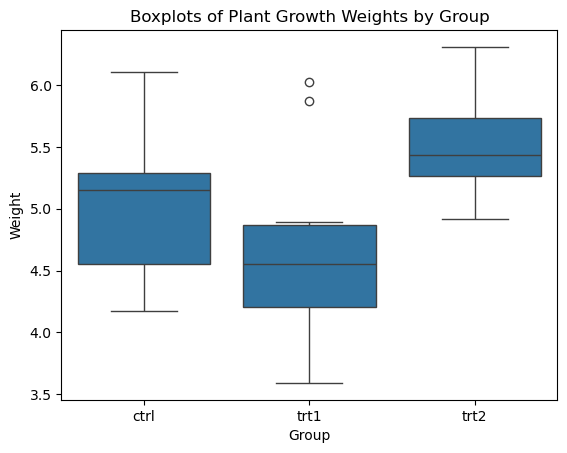

In [59]:
## b.) Make boxplots of weight separated by group in a single graph.

sns.boxplot(x='group', y='weight', data=PlantGrowth)

# Add titles and labels to boxplot
plt.title('Boxplots of Plant Growth Weights by Group')
plt.xlabel('Group')
plt.ylabel('Weight')

plt.show()

In [60]:
## c.) Based on the boxplots in 2b, approximately what percentage 
## of the "trt1" weights are below the minimum "trt2" weight?

# Calculate 5 number summaries for trt1 and trt2 for better 
# understanding of the data distribution side by side
stats = PlantGrowth.groupby("group")["weight"].describe()
print(stats[["min", "25%", "50%", "75%", "max"]])

'''
Visually looking at the boxplots in 2b, the min value (lower whisker)
for trt2 is at roughly 4.9. This value is confirmed upon calculating
the stats of the data. 
The third quartile line Q3 for trt1 is also at roughly 4.9, and since
Q3 marks the 75th percentile of a dataset, it appears approximately 
75% of the trt1 values are below the trt2 minimum. 
'''

        min     25%    50%     75%   max
group                                   
ctrl   4.17  4.5500  5.155  5.2925  6.11
trt1   3.59  4.2075  4.550  4.8700  6.03
trt2   4.92  5.2675  5.435  5.7350  6.31


'\nVisually looking at the boxplots in 2b, the min value (lower whisker)\nfor trt2 is at roughly 4.9. This value is confirmed upon calculating\nthe stats of the data. \nThe third quartile line Q3 for trt1 is also at roughly 4.9, and since\nQ3 marks the 75th percentile of a dataset, it appears approximately \n75% of the trt1 values are below the trt2 minimum. \n'

In [61]:
## d.) Find the exact percentage of the "trt1" weights that are 
## below the minimum "trt2" weight.

# Get minimum of trt2 and trt1 weights
min_trt2 = PlantGrowth[PlantGrowth["group"] == "trt2"]["weight"].min()
trt1_weights = PlantGrowth[PlantGrowth["group"] == "trt1"]["weight"]

# Calculate exact percentage of trt1 weights less than min_trt2
pct_below = (trt1_weights < min_trt2).mean() * 100

# Print answer, rounding to tenths for better formatting
print(f"\nMinimum trt2 weight: {min_trt2}")
print(f"Exact percentage of trt1 below min trt2: {pct_below:.1f}%")


Minimum trt2 weight: 4.92
Exact percentage of trt1 below min trt2: 80.0%


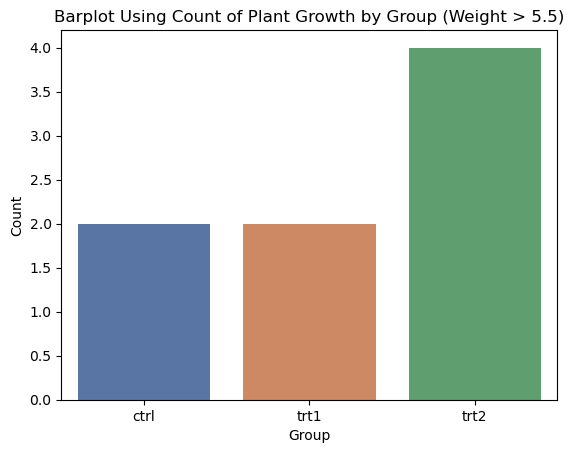

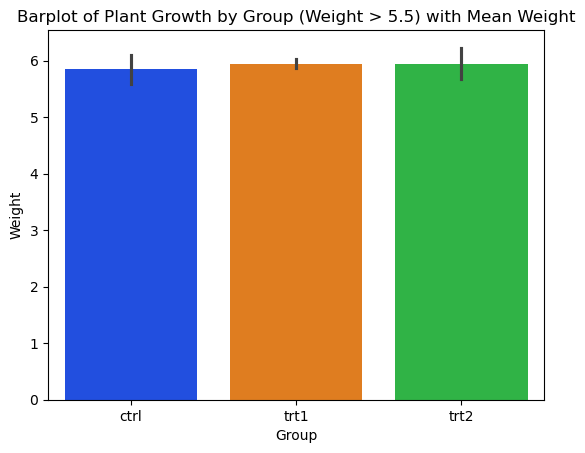

In [62]:
## e.) Only including plants with a weight above 5.5, make a barplot 
## of the variable group. Use some color palette 

# Using countplot to count occurances of each group w/ weight above 5.5
sns.countplot(
    x="group",
    data=PlantGrowth[PlantGrowth["weight"] > 5.5],
    hue="group",
    palette="deep",
    legend=False,
)

# Add titles and labels to barplot
plt.title("Barplot Using Count of Plant Growth by Group (Weight > 5.5)")
plt.xlabel("Group")
plt.ylabel("Count")

plt.show()

# Including seaborn barplot to show the mean weight of each group for comparison
sns.barplot(
    x='group', 
    y='weight', 
    data=PlantGrowth[PlantGrowth['weight'] > 5.5], 
    # Assign hue to group for color coding, using deep color palette
    hue='group',      
    palette="bright", 
    # Remove legend since hue is same as x-axis
    legend=False)

# Add titles and labels to barplot
plt.title('Barplot of Plant Growth by Group (Weight > 5.5) with Mean Weight')
plt.xlabel('Group')
plt.ylabel('Weight')    

plt.show()